In [1]:
# =========================
# 0) Setup e imports - Competencia Data Mining UBA 2025
# =========================
!pip -q install polars==1.7.1 sympy matplotlib seaborn google-cloud-storage

import polars as pl
from pathlib import Path
from types import SimpleNamespace
import json, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import optuna
from sympy import primerange
from google.cloud import storage

# Seeds oficiales de la competencia
SEEDS = [509963, 739373, 794341, 900623, 917827]
# Semillas adicionales (números primos grandes)
SEEDS_EXTRA = [1299827, 1500007, 1700021, 1900009, 2100013]
SEEDS_ALL = SEEDS + SEEDS_EXTRA  # 10 semillas totales

# Paths definitivos en Google Cloud / repo git
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
CSV_PATH    = PROJECT_ROOT / "datasets" / "competencia_02_crudo.csv"
SCHEMA_PATH = NOTEBOOK_DIR / "schema.json"
BASE_DIR    = NOTEBOOK_DIR / "dmeyf2025"

BUCKET_NAME = "nicocaviglia031_bukito3"
BUCKET_LOCAL_DIR = PROJECT_ROOT / BUCKET_NAME
BUCKET_LOCAL_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# =========================
# 1) Lectura de DF con Schema
# =========================

# Cargar schema
with open(SCHEMA_PATH) as f:
    schema_dict = json.load(f)

# Convertir strings a dtypes de Polars
schema = {k: getattr(pl, v) for k, v in schema_dict.items()}

# Lectura estricta (sin inferir tipos)
df = pl.read_csv(CSV_PATH, schema_overrides=schema)
df = df.rechunk()  # Compactar memoria

drop_cols = ["mprestamos_personales", "cprestamos_personales"]
df = df.drop(drop_cols)

df.shape

(4717958, 152)

In [3]:
# =========================
# 1.1) Canaritos + Setup de zLGBM
# =========================

def create_canaritos(df: pl.DataFrame, qcanaritos: int = 5) -> pl.DataFrame:
    """
    Añade un número específico de columnas "canarito" (features aleatorias)
    a un DataFrame de Polars.

    Estas nuevas columnas contendrán valores aleatorios uniformes (entre 0 y 1)
    y se colocarán al principio del DataFrame, manteniendo el orden
    original de las demás columnas.

    Args:
        df (pl.DataFrame): El DataFrame de Polars al que se le añadirán
                           las columnas.
        qcanaritos (int): El número de columnas "canarito" que se
                            desea crear (ej: 5).

    Returns:
        pl.DataFrame: Un nuevo DataFrame con las columnas "canarito" añadidas
                      al principio.
    """

    # 1. Guardar los nombres de las columnas originales
    original_cols = df.columns
    num_filas = df.height
    # 2. Generar la lista de nombres para las nuevas columnas "canarito"
    canary_cols = [f"canarito_{i}" for i in range(1, qcanaritos + 1)]

    # 3. Crear las expresiones Polars para generar los números aleatorios
    #    pl.rand_uniform(0, 1) es el equivalente a runif()
    canary_expressions = [pl.lit(np.random.rand(num_filas)).alias(name) for name in canary_cols]

    # 4. Añadir las nuevas columnas y reordenar todo en un solo paso
    #    Usamos .select() para el reordenamiento final
    df = df.with_columns(
        canary_expressions
    ).select(
        canary_cols + original_cols  # Concatena listas para el nuevo orden
    )

    return df

In [4]:
# =========================
# 2) Construcción de clase_ternaria (baseline del profesor)
# =========================

def agregar_clase_ternaria_optimizada(df: pl.DataFrame) -> pl.DataFrame:
    """
    Versión optimizada usando Polars - Baseline del profesor
    """
    return (
        df.lazy()
        .sort(["numero_de_cliente", "foto_mes"])
        .with_columns([
            pl.when(
                pl.col("foto_mes").shift(-1).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") != pl.col("foto_mes").max())
            ).then(pl.lit("BAJA+1"))
            .when(
                pl.col("foto_mes").shift(-2).over("numero_de_cliente").is_null() &
                (pl.col("foto_mes") <= pl.col("foto_mes").max() - 2)
            ).then(pl.lit("BAJA+2"))
            .otherwise(pl.lit("CONTINUA"))
            .alias("clase_ternaria")
        ])
        .collect()
    )

# Agregar la columna clase_ternaria
df = agregar_clase_ternaria_optimizada(df)

# Tabla de frecuencia de clase_ternaria por foto_mes
tabla_clases = (
    df.pivot(
        values="numero_de_cliente",
        index="foto_mes",
        on="clase_ternaria",
        aggregate_function="len"
    )
    .fill_null(0)
)

print(tabla_clases)

shape: (32, 4)
┌──────────┬──────────┬────────┬────────┐
│ foto_mes ┆ CONTINUA ┆ BAJA+2 ┆ BAJA+1 │
│ ---      ┆ ---      ┆ ---    ┆ ---    │
│ i64      ┆ u32      ┆ u32    ┆ u32    │
╞══════════╪══════════╪════════╪════════╡
│ 201901   ┆ 122918   ┆ 720    ┆ 635    │
│ 201902   ┆ 123985   ┆ 693    ┆ 723    │
│ 201903   ┆ 124535   ┆ 738    ┆ 694    │
│ 201904   ┆ 125293   ┆ 502    ┆ 743    │
│ 201905   ┆ 126016   ┆ 681    ┆ 505    │
│ …        ┆ …        ┆ …      ┆ …      │
│ 202104   ┆ 161340   ┆ 1126   ┆ 952    │
│ 202105   ┆ 161946   ┆ 842    ┆ 1129   │
│ 202106   ┆ 162336   ┆ 1135   ┆ 842    │
│ 202107   ┆ 163459   ┆ 0      ┆ 1137   │
│ 202108   ┆ 164822   ┆ 0      ┆ 0      │
└──────────┴──────────┴────────┴────────┘


In [5]:
# =========================
# Feature engineering: agregados de montos/contadores
# =========================

# Totales de saldos en pesos
SALDOS_PESOS = [
    "mcuenta_corriente",
    "mcaja_ahorro",
    "mcuenta_corriente_adicional",
    "mcaja_ahorro_adicional",
    "mcuentas_saldo",
]

# Totales de saldos en dólares
SALDOS_DOLARES = [
    "mcaja_ahorro_dolares",
]

# Consumo tarjetas pesos
CONSUMO_TARJETAS_PESOS = [
    "mtarjeta_visa_consumo",
    "mtarjeta_master_consumo",
]

# Consumo tarjetas dólares
CONSUMO_TARJETAS_DOLARES = [
    "Visa_mconsumosdolares",
    "Master_mconsumosdolares",
]

# Pagos recurrentes pesos
PAGOS_RECURRENTE_PESOS = [
    "mpagodeservicios",
    "mpagomiscuentas",
    "mcuenta_debitos_automaticos",
    "mttarjeta_visa_debitos_automaticos",
    "mttarjeta_master_debitos_automaticos",
]

# Sumas de productos de inversión y plazos fijos pesos
INVERSIONES_PESOS = [
    "mplazo_fijo_pesos",
    "minversion1_pesos",
    "minversion2",
]

# Sumas de productos de inversión y plazos fijos dólares
INVERSIONES_DOLARES = [
    "mplazo_fijo_dolares",
    "minversion1_dolares",
]

# Endeudamiento total pesos
ENDEUDAMIENTO_PESOS = [
    "mprestamos_prendarios",
    "mprestamos_hipotecarios",
    "Master_msaldopesos",
    "Visa_msaldopesos",
    "Master_madelantopesos",
    "Visa_madelantopesos",
]

# Endeudamiento total dólares
ENDEUDAMIENTO_DOLARES = [
    "Master_msaldodolares",
    "Visa_msaldodolares",
    "Master_madelantodolares",
    "Visa_madelantodolares",
]

# Ingresos payroll pesos
PAYROLL_PESOS = [
    "mpayroll",
    "mpayroll2",
]

# Límites de compra
LIMITES_COMPRA = [
    "Master_mlimitecompra",
    "Visa_mlimitecompra",
]

# Suma de seguros contratados
SEGUROS_COUNT = [
    "cseguro_vida",
    "cseguro_auto",
    "cseguro_vivienda",
    "cseguro_accidentes_personales",
]

# Totales de transacciones (conteo)
TRANSACCIONES_COUNT = [
    "ctarjeta_debito_transacciones",
    "ctarjeta_visa_transacciones",
    "ctarjeta_master_transacciones",
    "chomebanking_transacciones",
    "cmobile_app_trx",
    "ccallcenter_transacciones",
    "catm_trx",
    "catm_trx_other",
    "ccajas_transacciones",
]

def sum_columns_safe(df: pl.DataFrame, cols: list[str]) -> pl.Series:
    existentes = [c for c in cols if c in df.columns]
    if not existentes:
        return pl.lit(0)
    return pl.sum_horizontal([pl.col(c) for c in existentes])

fe_columns = {
    "m_saldo_total_pesos": SALDOS_PESOS,
    "m_saldo_total_dolares": SALDOS_DOLARES,
    "m_consumo_tarjetas_pesos": CONSUMO_TARJETAS_PESOS,
    "m_consumo_tarjetas_dolares": CONSUMO_TARJETAS_DOLARES,
    "m_pagos_recurrentes_pesos": PAGOS_RECURRENTE_PESOS,
    "m_inversiones_pesos": INVERSIONES_PESOS,
    "m_inversiones_dolares": INVERSIONES_DOLARES,
    "m_endeudamiento_pesos": ENDEUDAMIENTO_PESOS,
    "m_endeudamiento_dolares": ENDEUDAMIENTO_DOLARES,
    "m_payroll_total": PAYROLL_PESOS,
    "m_limite_compra_total": LIMITES_COMPRA,
    "c_seguros_total": SEGUROS_COUNT,
    "c_transacciones_total": TRANSACCIONES_COUNT,
}

df = df.with_columns([
    sum_columns_safe(df, cols).alias(col_name)
    for col_name, cols in fe_columns.items()
])

df.shape

(4717958, 166)

In [6]:
# =========================
# 4) Feature Engineering Histórico - Lags y DeltaLags
# =========================

# Excluir IDs y metadata
EXCLUDE = {"numero_de_cliente", "foto_mes", "clase_ternaria"}

# Identificar columnas numéricas
num_cols = [c for c, dt in zip(df.columns, df.dtypes)
            if c not in EXCLUDE and dt.is_numeric()]

def add_lags_and_deltas(df: pl.DataFrame, cols: list[str]) -> pl.DataFrame:
    """
    Agregar lags y deltas de orden 1 y 2 - Baseline del profesor
    """
    out = df.sort(["numero_de_cliente", "foto_mes"]).lazy()

    # Lags 1 y 2
    out = out.with_columns([
        pl.col(c).shift(1).over("numero_de_cliente").alias(f"{c}_lag1") for c in cols
    ] + [
        pl.col(c).shift(2).over("numero_de_cliente").alias(f"{c}_lag2") for c in cols
    ])

    # Delta 1: x_t - x_{t-1} ; Delta 2: x_t - x_{t-2}
    out = out.with_columns([
        (pl.col(c) - pl.col(f"{c}_lag1")).alias(f"{c}_d1") for c in cols
    ] + [
        (pl.col(c) - pl.col(f"{c}_lag2")).alias(f"{c}_d2") for c in cols
    ])

    return out.collect()

# Aplicar lags y deltas
df = add_lags_and_deltas(df, num_cols)

df.shape

(4717958, 818)

In [7]:
# =========================
# 4.1) Creacion de Canaritos
# =========================

plocal = SimpleNamespace(
    qcanaritos=5,
    min_data_in_leaf=20,
    learning_rate=1.0,
    gradient_bound=0.1,
    APO=5,
    ksemillerio=1,
)

df = create_canaritos(df, plocal.qcanaritos)

In [8]:
# Configuración de la competencia
TRAIN_MESES = [
    202004, 202005, 202007,
    202008, 202009, 202010,
    202011, 202012, 202101,
    202102, 202103, 202104,
    202105, 202106,
]  # Meses de entrenamiento

# TEST_MES   = 202106                            # Solo para mantener compatibilidad con algunas celdas

APPLY_MES = 202108                             # Mes objetivo


In [9]:
# =========================
# 5) Undersampling de clientes CONTINUA repetidos en todos los meses de entrenamiento
# =========================

TRAIN_MESES_SET = set(TRAIN_MESES)
TOTAL_MESES_TRAIN = len(TRAIN_MESES_SET)

train_subset = df.filter(pl.col("foto_mes").is_in(TRAIN_MESES))

clientes_continua_full = (
    train_subset
    .group_by("numero_de_cliente")
    .agg([
        pl.col("clase_ternaria").eq("CONTINUA").all().alias("solo_continua"),
        pl.col("foto_mes").n_unique().alias("n_meses"),
    ])
    .filter(
        pl.col("solo_continua") &
        (pl.col("n_meses") == TOTAL_MESES_TRAIN)
    )
    .select("numero_de_cliente")
)

clientes_continua_list = clientes_continua_full.get_column("numero_de_cliente").to_list()

fraccion_sample = 0.05
n_total_continua = len(clientes_continua_list)
if n_total_continua > 0:
    n_sample = max(1, int(np.ceil(n_total_continua * fraccion_sample)))
    clientes_sample = clientes_continua_full.sample(n=n_sample, seed=SEEDS[0])
    clientes_sample_list = clientes_sample.get_column("numero_de_cliente").to_list()
else:
    clientes_sample_list = []

clientes_a_excluir = set(clientes_continua_list) - set(clientes_sample_list)

print(f"Clientes CONTINUA en todos los meses de train: {n_total_continua}")
print(f"Clientes CONTINUA retenidos (5%): {len(clientes_sample_list)}")

_df_train = train_subset.filter(~pl.col("numero_de_cliente").is_in(list(clientes_a_excluir)))
# _df_test = df.filter(pl.col("foto_mes") == TEST_MES)
_df_apply = df.filter(pl.col("foto_mes") == APPLY_MES)

Clientes CONTINUA en todos los meses de train: 138924
Clientes CONTINUA retenidos (5%): 6947


In [10]:
# =========================
# 5.1) Validación de la data
# =========================

print("_df_train shape:", _df_train.shape)
#print("_df_test shape:", _df_test.shape)
print("_df_apply shape:", _df_apply.shape)
print("Primeras columnas en df      :", df.columns[:10])
print("Primeras columnas en _df_train:", _df_train.columns[:10])

_df_train shape: (380569, 823)
_df_apply shape: (164822, 823)
Primeras columnas en df      : ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet']
Primeras columnas en _df_train: ['canarito_1', 'canarito_2', 'canarito_3', 'canarito_4', 'canarito_5', 'numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet']


In [11]:
# =========================
# 6) Entrenamiento LightGBM con métrica de ganancia
# =========================

plocal = SimpleNamespace(
    qcanaritos=5,
    min_data_in_leaf=20,
    learning_rate=1.0,
    gradient_bound=0.1,
    APO=5,
    ksemillerio=1,
)

PARAM = SimpleNamespace(
    semilla_primigenia=SEEDS[0],
    qcanaritos=plocal.qcanaritos,
)

# Constantes de ganancia
GANANCIA_ACIERTO = 780000
COSTO_ESTIMULO = 20000

def calcular_ganancias_acumuladas(y_true, y_pred_proba):
    """Calcula la ganancia acumulada ordenando por probabilidad descendente."""
    df_eval = pl.DataFrame({"y_true": y_true, "y_pred_proba": y_pred_proba})
    df_ordenado = df_eval.sort("y_pred_proba", descending=True)
    df_ordenado = df_ordenado.with_columns(
        pl.when(pl.col("y_true") == 1)
        .then(GANANCIA_ACIERTO)
        .otherwise(-COSTO_ESTIMULO)
        .alias("ganancia_individual")
    )
    df_ordenado = df_ordenado.with_columns(
        pl.col("ganancia_individual").cast(pl.Int64).cum_sum().alias("ganancia_acumulada")
    )
    return df_ordenado["ganancia_acumulada"].to_numpy()


train_pd = _df_train.to_pandas()
# test_pd = _df_test.to_pandas()
apply_pd = _df_apply.to_pandas()

rng = np.random.default_rng(PARAM.semilla_primigenia)

drop_cols = {"numero_de_cliente", "foto_mes", "clase_ternaria"}
feature_cols = [c for c in train_pd.columns if c not in drop_cols]

print("=== Dataset shapes ===")
# print(f"train: {train_pd.shape} | test: {test_pd.shape} | apply: {apply_pd.shape}")
print(f"Features disponibles: {len(feature_cols)} (incluye canaritos={plocal.qcanaritos})")

y_train = train_pd["clase_ternaria"].isin(["BAJA+1", "BAJA+2"]).astype(int)
weight_train = np.where(y_train == 1, 1.00002, 1.0)

lgb_train = lgb.Dataset(train_pd[feature_cols], label=y_train, weight=weight_train)

lgbm_param_completo = {
    "boosting": "gbdt",
    "objective": "binary",
    "metric": "None",
    "first_metric_only": False,
    "boost_from_average": True,
    "feature_pre_filter": False,
    "force_row_wise": True,
    "verbosity": -100,
    "seed": PARAM.semilla_primigenia,
    "max_bin": 31,
    "min_data_in_leaf": plocal.min_data_in_leaf,
    "num_leaves": 9999,
    "learning_rate": plocal.learning_rate,
    "feature_fraction": 0.50,
    "canaritos": PARAM.qcanaritos,
    "gradient_bound": plocal.gradient_bound,
}

num_boost_round = 9999

print("\n=== Hyperparámetros principales ===")
print(
    f"seed={lgbm_param_completo['seed']} | min_leaf={plocal.min_data_in_leaf} | "
    f"learning_rate={plocal.learning_rate} | num_leaves={lgbm_param_completo['num_leaves']}"
)
print(
    f"canaritos={PARAM.qcanaritos} | gradient_bound={plocal.gradient_bound} | "
    f"feature_fraction={lgbm_param_completo['feature_fraction']} | rounds={num_boost_round}"
)

model = lgb.train(
    lgbm_param_completo,
    train_set=lgb_train,
    num_boost_round=num_boost_round,
)

best_iteration = model.best_iteration or num_boost_round
apply_pd["pred_lgbm"] = model.predict(apply_pd[feature_cols], num_iteration=best_iteration)

# valid_scores = model.predict(test_pd[feature_cols], num_iteration=best_iteration)


=== Dataset shapes ===
Features disponibles: 820 (incluye canaritos=5)

=== Hyperparámetros principales ===
seed=509963 | min_leaf=20 | learning_rate=1.0 | num_leaves=9999
canaritos=5 | gradient_bound=0.1 | feature_fraction=0.5 | rounds=9999


In [12]:
# =========================
# 7) Ganancia real en TEST 202104
# =========================

#test_pred_df = (
 #   pl.DataFrame(
  #      {
   #         "numero_de_cliente": test_pd["numero_de_cliente"],
    #        "foto_mes": test_pd["foto_mes"],
     #       "clase_ternaria": test_pd["clase_ternaria"],
      #      "probabilidad_baja": valid_scores,
       # }
#    )
 #   .with_columns(
  #      pl.col("clase_ternaria").eq("BAJA+2").cast(pl.Int64).alias("es_baja2")
   # )
    #.sort("probabilidad_baja", descending=True)
#    .with_row_count("rank_envio", offset=1)
#)

#ganancias_acumuladas = calcular_ganancias_acumuladas(
 #   test_pred_df["es_baja2"].to_numpy(),
  #  test_pred_df["probabilidad_baja"].to_numpy(),
#)

#test_pred_df = test_pred_df.with_columns(
#    pl.Series("ganancia_acumulada", ganancias_acumuladas)
#)

#ganancia_maxima = float(ganancias_acumuladas.max())
#idx_mejor = int(np.argmax(ganancias_acumuladas))
#n_envios_optimo = idx_mejor + 1

#ganancia_envio_11000 = (
#    int(ganancias_acumuladas[10999])
#    if len(ganancias_acumuladas) >= 11000
#    else None
#)

# print("=== Ganancia TEST 202106 ===")
#print(f"Ganancia máxima: {ganancia_maxima:,.0f}")
#print(f"Envíos óptimos: {n_envios_optimo} clientes")
#if ganancia_envio_11000 is not None:
#    print(f"Ganancia en 11.000 envíos: {ganancia_envio_11000:,.0f}")
#else:
#    print("Ganancia en 11.000 envíos: N/A (menos registros)")


Top 10 features por gain
                       feature           gain  split
108               ctrx_quarter  275608.639745  73775
52                cpayroll_trx  160536.256011   3678
128           Master_fechaalta  140930.089158  29211
271          ctrx_quarter_lag1  117623.149252  43484
291      Master_fechaalta_lag1   92200.472179  24317
73   mcomisiones_mantenimiento   87989.577893  17304
164            m_payroll_total   86208.641005  15412
378          cpayroll_trx_lag2   84881.950461   3552
157   m_consumo_tarjetas_pesos   76312.038766  26160
155        m_saldo_total_pesos   74022.275481  36585


/tmp/ipykernel_3601/628038026.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


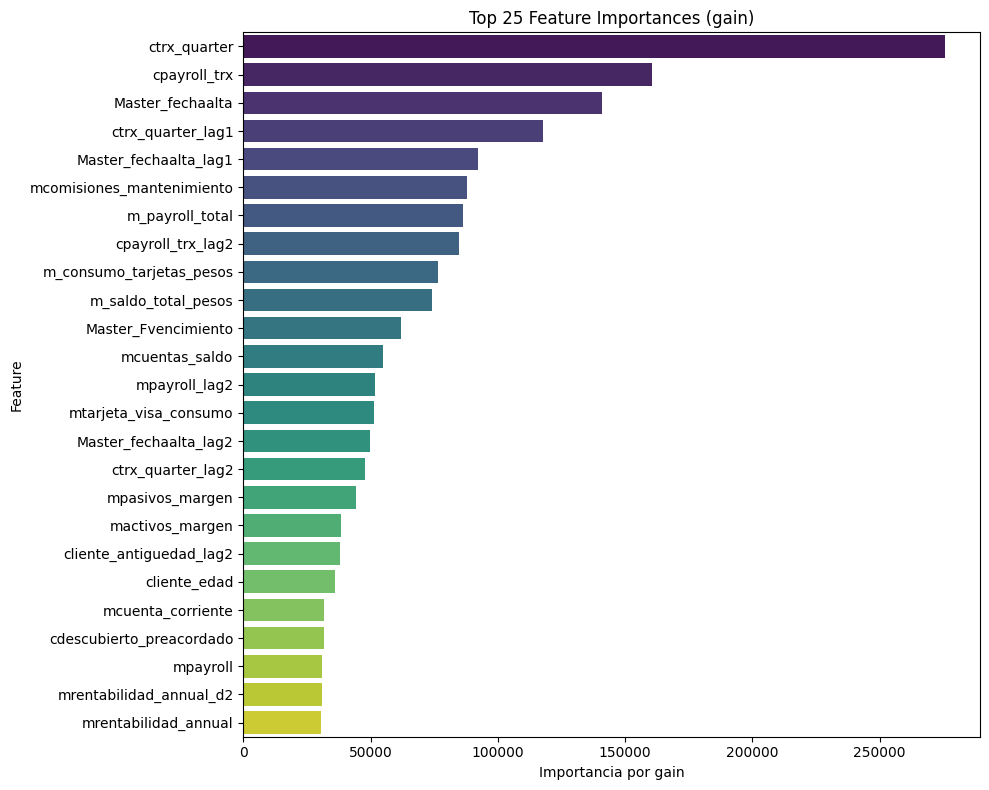

In [13]:
# =========================
# 8) Feature importance del modelo LightGBM
# =========================

feature_importance_gain = model.feature_importance(importance_type="gain")
feature_importance_split = model.feature_importance(importance_type="split")

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "gain": feature_importance_gain,
            "split": feature_importance_split,
        }
    )
    .sort_values("gain", ascending=False)
)

print("Top 10 features por gain")
print(importance_df.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(25),
    x="gain",
    y="feature",
    palette="viridis",
)
plt.title("Top 25 Feature Importances (gain)")
plt.xlabel("Importancia por gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



In [22]:
# =========================
# 9) Predicciones binarias finales y archivo submit
# =========================

models = [model]
predictions_per_seed = [apply_pd["pred_lgbm"].to_numpy()]

predictions_matrix = np.vstack(predictions_per_seed)
final_predictions = np.mean(predictions_matrix, axis=0)

clientes_ordenados = np.argsort(final_predictions)[::-1]

n_clientes_objetivo = 11000
predicciones_binarias = np.zeros(len(final_predictions), dtype=int)
predicciones_binarias[clientes_ordenados[:n_clientes_objetivo]] = 1

id_apply = apply_pd["numero_de_cliente"].to_numpy()
submit_df = pd.DataFrame(
    {
        "numero_de_cliente": id_apply[clientes_ordenados],
        "Predicted": predicciones_binarias[clientes_ordenados],
    }
)

submit_df

submit_path = BASE_DIR / "202108_submit_lgbm.csv"
submit_path.parent.mkdir(parents=True, exist_ok=True)
submit_df.to_csv(submit_path, index=False)

print("=== Submit APPLY listo ===")
print(f"Archivo: {submit_path}")
print(f"Clientes positivos: {predicciones_binarias.sum()} de {len(predicciones_binarias)}")

#clientes_valid_ordenados = np.argsort(valid_scores)[::-1]
#predicciones_binarias_valid = np.zeros(len(valid_scores), dtype=int)
#predicciones_binarias_valid[clientes_valid_ordenados[:n_clientes_objetivo]] = 1

#id_valid = test_pd["numero_de_cliente"].to_numpy()
#submit_valid_df = pl.DataFrame(
#    {
#        "numero_de_cliente": id_valid[clientes_valid_ordenados],
#        "Predicted": predicciones_binarias_valid[clientes_valid_ordenados],
#    }
#)

#submit_valid_path = BASE_DIR / "submit_lgbm_test202106.csv"
#submit_valid_df.write_csv(submit_valid_path)

#print("\n=== Submit TEST 202106 listo ===")
#print(f"Archivo: {submit_valid_path}")
#print(f"Clientes positivos: {predicciones_binarias_valid.sum()} de {len(predicciones_binarias_valid)}")

=== Submit APPLY listo ===
Archivo: /home/nicocaviglia031/dmeyf2025/Competencia 2/dmeyf2025/202108_submit_lgbm.csv
Clientes positivos: 11000 de 164822


In [24]:
# Filtrar los clientes con Predicted == 1
df_filtered_ensemble = submit_df[submit_df["Predicted"] == 1][["numero_de_cliente"]]
# Guardar CSV sin encabezados ni índice
df_filtered_ensemble.to_csv("Charizard777.csv", index=False, header=False)

(11000, 1)
